Question 02

Earring 1:
Width  = 369 pixels = 73.06 mm
Height = 377 pixels = 74.65 mm

Earring 2:
Width  = 367 pixels = 72.67 mm
Height = 376 pixels = 74.45 mm



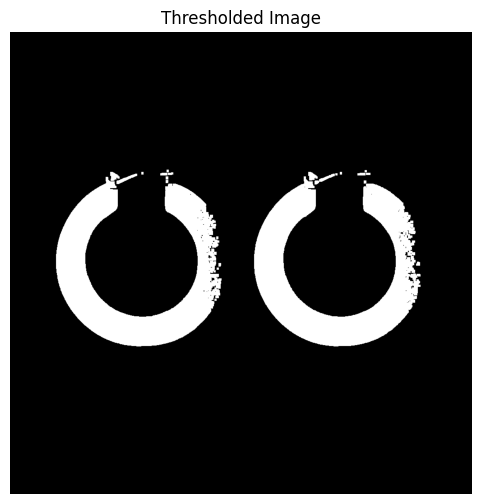

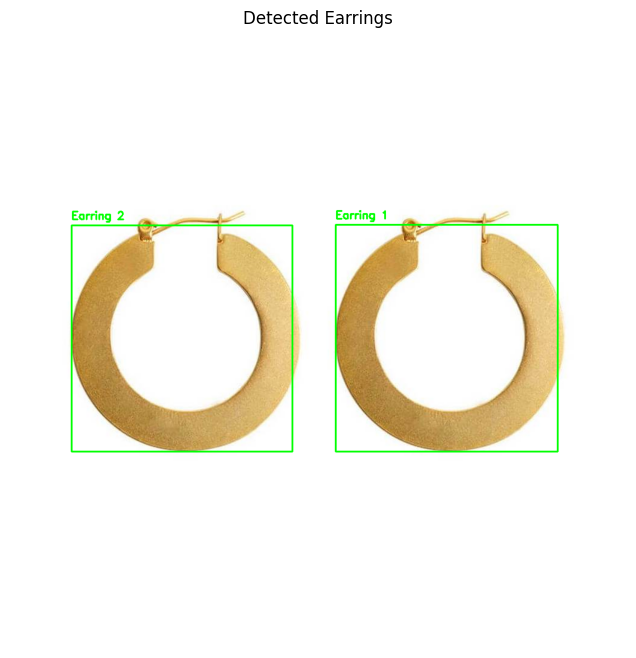

In [ ]:
#Question 02 

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("earrings.jpg")
img_copy = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold using Otsu
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by area, largest first
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Scale factor
scale = 0.198   # mm per pixel

count = 1
for cnt in contours:
    area = cv2.contourArea(cnt)

    # Ignore very small regions
    if area < 500:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    real_w = w * scale
    real_h = h * scale

    print(f"Earring {count}:")
    print(f"Width  = {w} pixels = {real_w:.2f} mm")
    print(f"Height = {h} pixels = {real_h:.2f} mm\n")

    # Draw rectangle and label
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_copy, f"Earring {count}", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    count += 1

    # Stop after detecting 2 earrings
    if count > 2:
        break

# Show threshold image
plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

# Show detected earrings
img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.title("Detected Earrings")
plt.axis("off")
plt.show()